# Final HMM Regime Analysis (Stage 10D)

## 1. Purpose and research role

The hidden state represents an unobserved market condition. The selected HMM identifies these conditions from daily log return, leakage-safe train-fitted GARCH volatility, and 252-trading-day drawdown. Volume and VIX were deliberately excluded from regime formation so they can later be evaluated independently. This notebook interprets finalized regimes; it does **not** establish whether volume predicts future transitions, refit a model, or perform statistical testing.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display
from market_regime.plots import create_hmm_diagnostic_figures

ROOT = Path.cwd()
if not (ROOT / 'outputs').exists() and ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'outputs' / 'tables' / 'market_with_hmm.csv').exists(), 'Repository outputs were not found.'
TABLES, MODELS, FIGURES = ROOT/'outputs'/'tables', ROOT/'outputs'/'models', ROOT/'outputs'/'figures'
market = pd.read_csv(TABLES/'market_with_hmm.csv', parse_dates=['Date'])
profiles = pd.read_csv(TABLES/'hmm_selected_model_profile.csv')
transition = pd.read_csv(TABLES/'hmm_selected_transition_matrix.csv')
durations = pd.read_csv(TABLES/'hmm_selected_state_durations.csv')
assignment = pd.read_csv(TABLES/'hmm_assignment_summary.csv')
metadata = json.loads((MODELS/'hmm_selected_model_metadata.json').read_text())
print(f"Loaded {len(market):,} rows ({market.HMM_Eligible.sum():,} eligible) from saved Stage 10C2 outputs.")

Loaded 6,641 rows (6,390 eligible) from saved Stage 10C2 outputs.


## 2. Model specification

The observation vector is

$$X_t=[\mathrm{Log\_Return}_t,\;\mathrm{GARCH\_Volatility\_TrainFit}_t,\;\mathrm{Drawdown\_252}_t]'$$

and the transition probability is

$$P(S_t=j\mid S_{t-1}=i)=p_{ij}.$$

The selected Gaussian HMM has four states, diagonal covariance, and seed 44. Diagonal covariance allows each feature to have a different state-specific variance while constraining contemporaneous within-state covariance terms to zero. Selection considered convergence, stability across starts, state sizes, durations, interpretability, and BIC collectivelyâ€”not BIC alone. Parameters and the training-only scaler were fixed through 2017-12-31.

In [2]:
pd.DataFrame({
    'Specification': ['States', 'Covariance', 'Seed', 'Training cutoff', 'Training log likelihood', 'BIC'],
    'Value': [metadata['K'], metadata['covariance_type'], metadata['seed'], metadata['training_cutoff'],
              metadata['reconstructed_log_likelihood'], metadata['reconstructed_BIC']]
})

,Specification,Value
0,States,4
1,Covariance,diag
2,Seed,44
3,Training cutoff,2017-12-31
4,Training log likelihood,-4650.130091
5,BIC,9626.33946


## 3. State ordering and training-period profiles

Original states were ordered using training-period profiles only: lower mean GARCH volatility first, then less-negative drawdown, then higher mean return. The official machine-readable labels remain `Ordered_State_1` through `Ordered_State_4`. The descriptions below are provisional post-estimation interpretations and use neither volume nor VIX: State 1 calm/growth, State 2 normal/moderate, State 3 elevated stress, and State 4 acute stress.

In [3]:
interpretation = {1:'calm/growth', 2:'normal/moderate', 3:'elevated stress', 4:'acute stress'}
profile_display = profiles.copy()
profile_display['Provisional_Interpretation'] = profile_display['Ordered_State'].map(interpretation)
profile_display[['Ordered_State','Original_State','Neutral_State_Label','Provisional_Interpretation','count','percentage',
                 'mean_Log_Return','mean_GARCH_Volatility_TrainFit','mean_Drawdown_252']].round(6)

,Ordered_State,Original_State,Neutral_State_Label,Provisional_Interpretation,count,percentage,mean_Log_Return,mean_GARCH_Volatility_TrainFit,mean_Drawdown_252
0,1,3,Ordered_State_1,calm/growth,1548,36.193594,0.000998,0.006218,-0.004950
1,2,2,Ordered_State_2,normal/moderate,1306,30.535422,0.000129,0.009002,-0.028110
2,3,0,Ordered_State_3,elevated stress,1065,24.900631,-0.000289,0.013593,-0.142688
3,4,1,Ordered_State_4,acute stress,358,8.370353,-0.001086,0.025762,-0.313508


The profile chart expresses feature means in standard deviations of the saved training scaler, avoiding a misleading common axis for incompatible raw units.

## 4. Filtered versus smoothed probabilities

Filtered probabilities are $P(S_t=k\mid X_1,\ldots,X_t)$ and are appropriate for real-time analysis. Smoothed probabilities are $P(S_t=k\mid X_1,\ldots,X_T)$ and use later observations, so they are retrospective only. `HMM_Filtered_State` is the primary series for future prediction work; smoothed states are diagnostic and descriptive.

In [4]:
assignment.loc[assignment.metric.isin(['filtered_low_confidence','smoothed_low_confidence','filtered_smoothed_agreement']),
               ['sample','metric','count','percentage']].round(3)

,sample,metric,count,percentage
4,Train,filtered_low_confidence,73,1.707
9,Train,smoothed_low_confidence,50,1.169
10,Train,filtered_smoothed_agreement,4066,95.067
15,Test,filtered_low_confidence,29,1.372
20,Test,smoothed_low_confidence,38,1.798
21,Test,filtered_smoothed_agreement,1991,94.226


## 5. Transition probabilities and durations

Each transition-matrix row conditions on the current state and each column is the next state. Diagonal entries are self-transition probabilities. Tiny saved probabilities are not necessarily mathematically impossible merely because a displayed value rounds toward zero. Model-implied expected duration is

$$E[D_i]=\frac{1}{1-p_{ii}}.$$

This geometric-model quantity differs from empirical mean and median episode durations in the training-period decoding.

In [5]:
display(transition)
durations[['Ordered_State','self_transition_probability','model_implied_expected_duration','episode_count',
           'empirical_mean_duration','empirical_median_duration','minimum_duration','maximum_duration']].round(3)

,From_State,Ordered_State_1,Ordered_State_2,Ordered_State_3,Ordered_State_4,Row_Sum
0,Ordered_State_1,9.692273e-01,2.971630e-02,0.001056,9.157778e-123,1.0
1,Ordered_State_2,3.723024e-02,9.549474e-01,0.007822,9.595577e-171,1.0
2,Ordered_State_3,2.241980e-231,1.191756e-02,0.982741,5.341528e-03,1.0
3,Ordered_State_4,0.000000e+00,9.611667e-250,0.016268,9.837324e-01,1.0


,Ordered_State,self_transition_probability,model_implied_expected_duration,episode_count,empirical_mean_duration,empirical_median_duration,minimum_duration,maximum_duration
0,1,0.969,32.496,44.0,35.182,27.0,4,192
1,2,0.955,22.196,53.0,24.642,18.0,3,86
2,3,0.983,57.940,17.0,62.647,38.0,4,214
3,4,0.984,61.472,5.0,71.600,28.0,13,210


## 6. Train/test regime distribution

Filtered and smoothed distributions are reported separately. Filtered State 4 declines from 8.44% in training to 3.83% in testing. This is a sample-composition finding, not evidence of model failure; no statistical test is conducted here.

In [6]:
assignment.loc[assignment.metric.isin(['filtered_state','smoothed_state']),
               ['sample','metric','state','count','percentage']].round(3)

,sample,metric,state,count,percentage
0,Train,filtered_state,1.0,1492,34.884
1,Train,filtered_state,2.0,1337,31.260
2,Train,filtered_state,3.0,1087,25.415
3,Train,filtered_state,4.0,361,8.440
5,Train,smoothed_state,1.0,1545,36.123
6,Train,smoothed_state,2.0,1304,30.489
7,Train,smoothed_state,3.0,1075,25.134
8,Train,smoothed_state,4.0,353,8.253
11,Test,filtered_state,1.0,706,33.412
12,Test,filtered_state,2.0,724,34.264


## 7. Publication-quality diagnostic figures

All figures below are generated solely from saved Stage 10C2 tables and metadata. Colors consistently run from green/teal for Ordered State 1 through red for Ordered State 4.

In [7]:
figure_paths = create_hmm_diagnostic_figures(market, profiles, transition, durations, assignment, metadata, FIGURES)
for path in figure_paths:
    assert path.exists() and path.stat().st_size > 0
    print(path.relative_to(ROOT), f"({path.stat().st_size:,} bytes)")

outputs\figures\hmm_filtered_regimes_price.png (153,546 bytes)
outputs\figures\hmm_filtered_regime_features.png (518,388 bytes)
outputs\figures\hmm_filtered_probabilities.png (407,533 bytes)
outputs\figures\hmm_smoothed_probabilities.png (382,589 bytes)
outputs\figures\hmm_transition_matrix.png (92,433 bytes)
outputs\figures\hmm_state_profiles.png (49,980 bytes)
outputs\figures\hmm_state_durations.png (60,294 bytes)
outputs\figures\hmm_train_test_distributions.png (50,341 bytes)
outputs\figures\hmm_classification_confidence.png (55,369 bytes)
outputs\figures\hmm_filtered_smoothed_agreement.png (87,345 bytes)


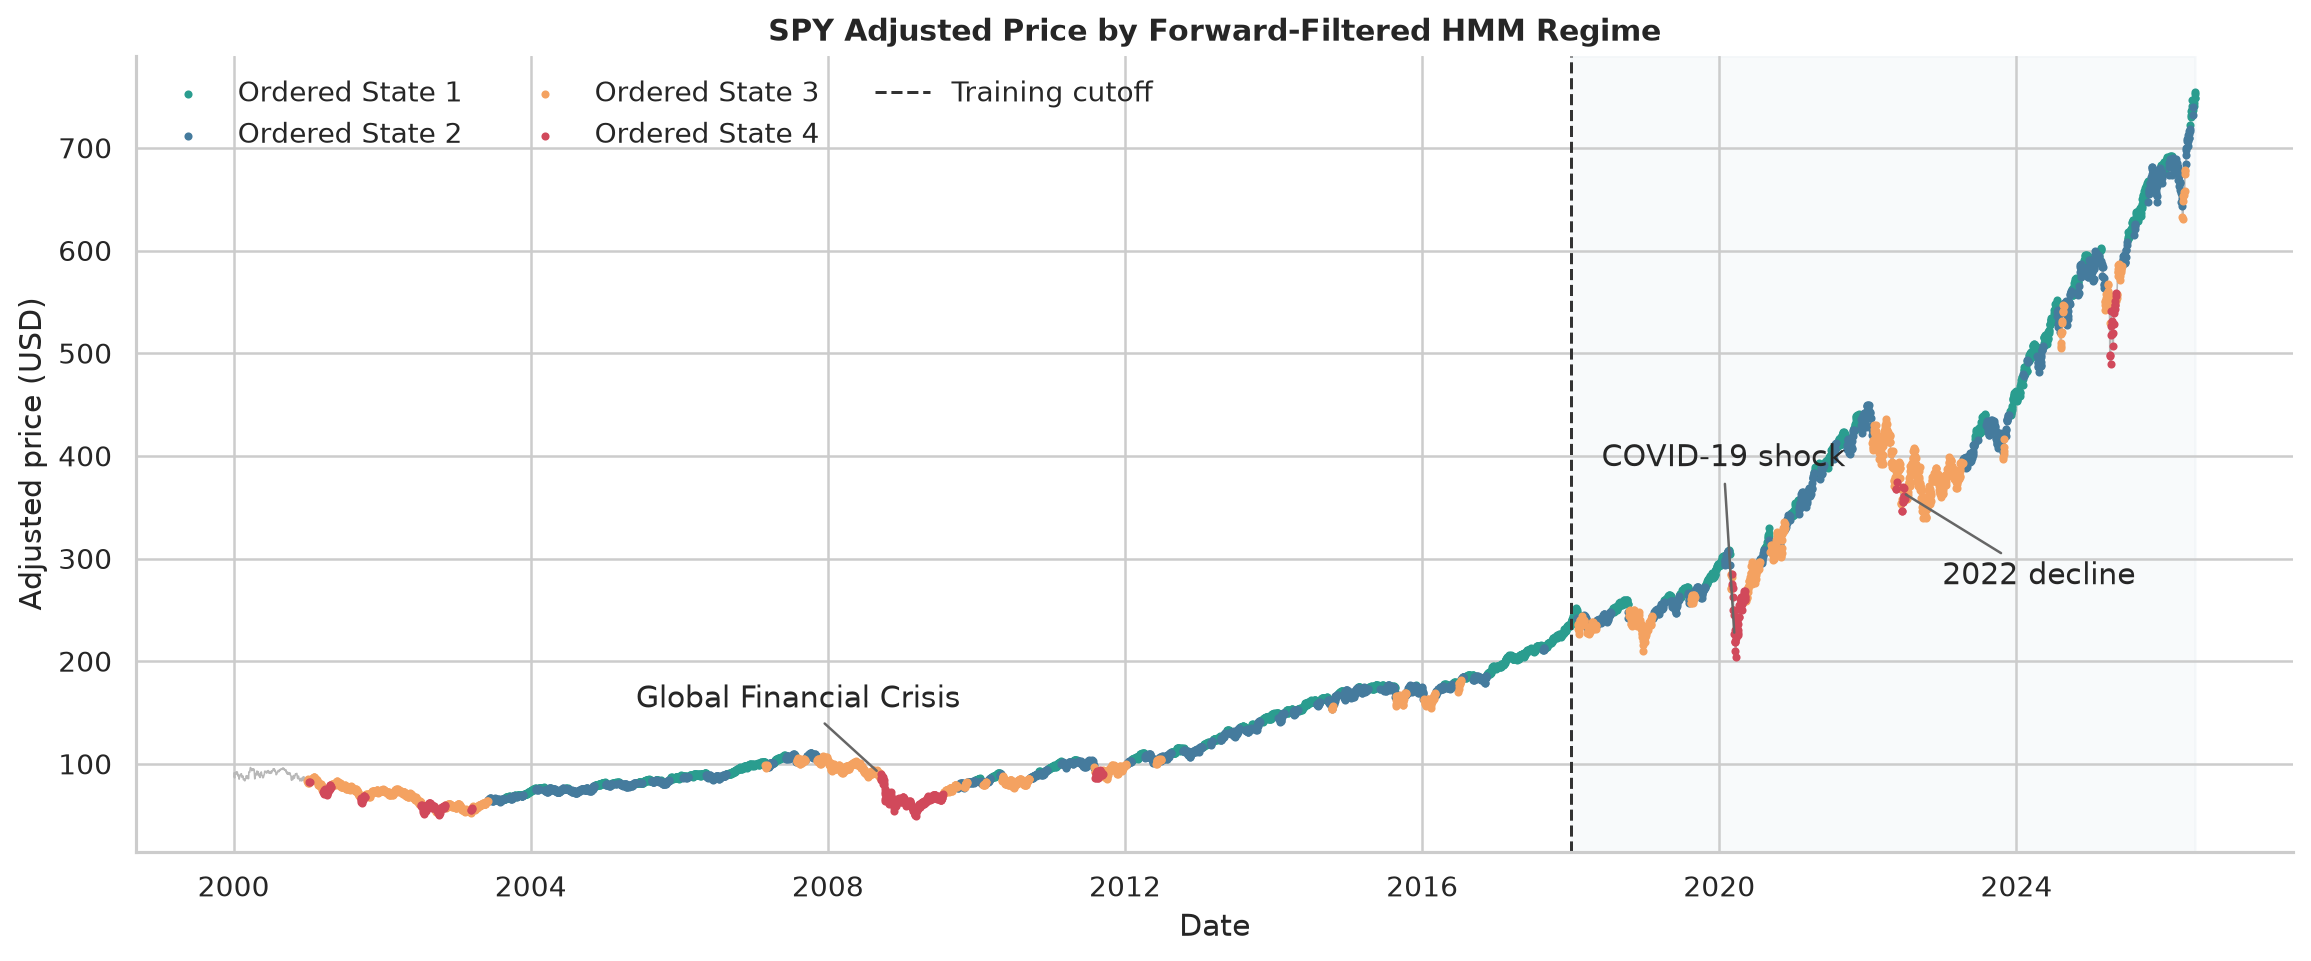

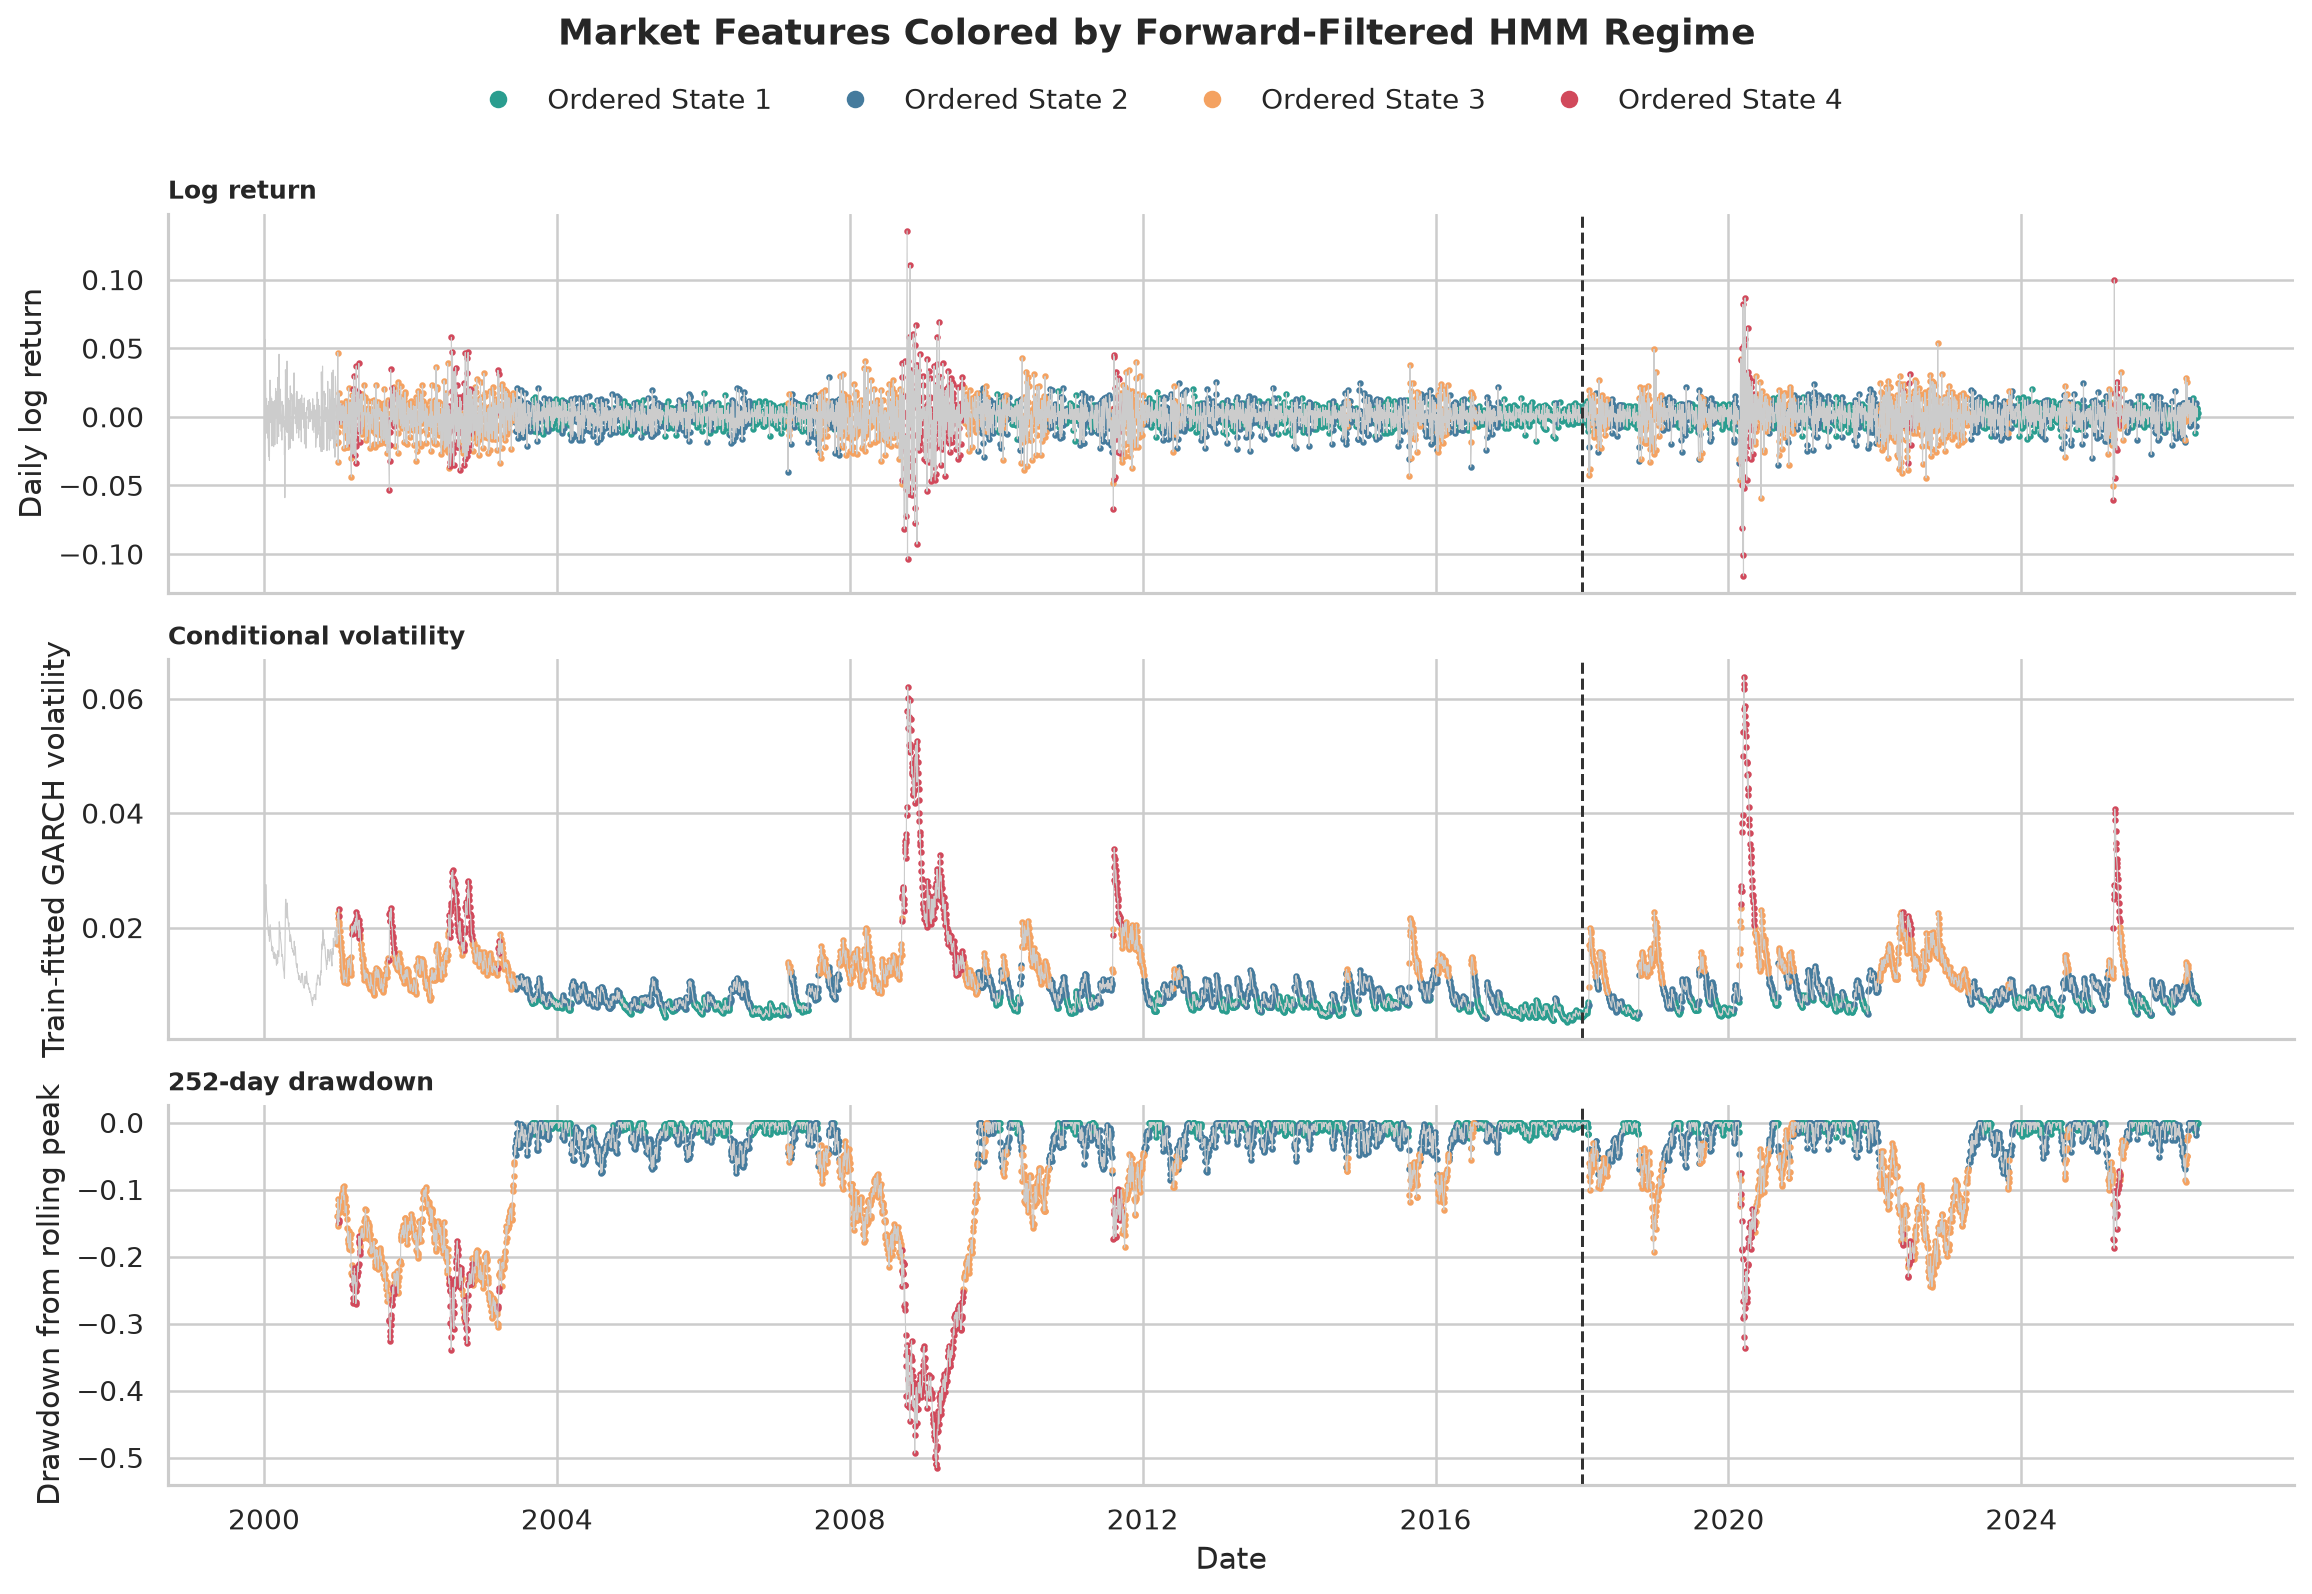

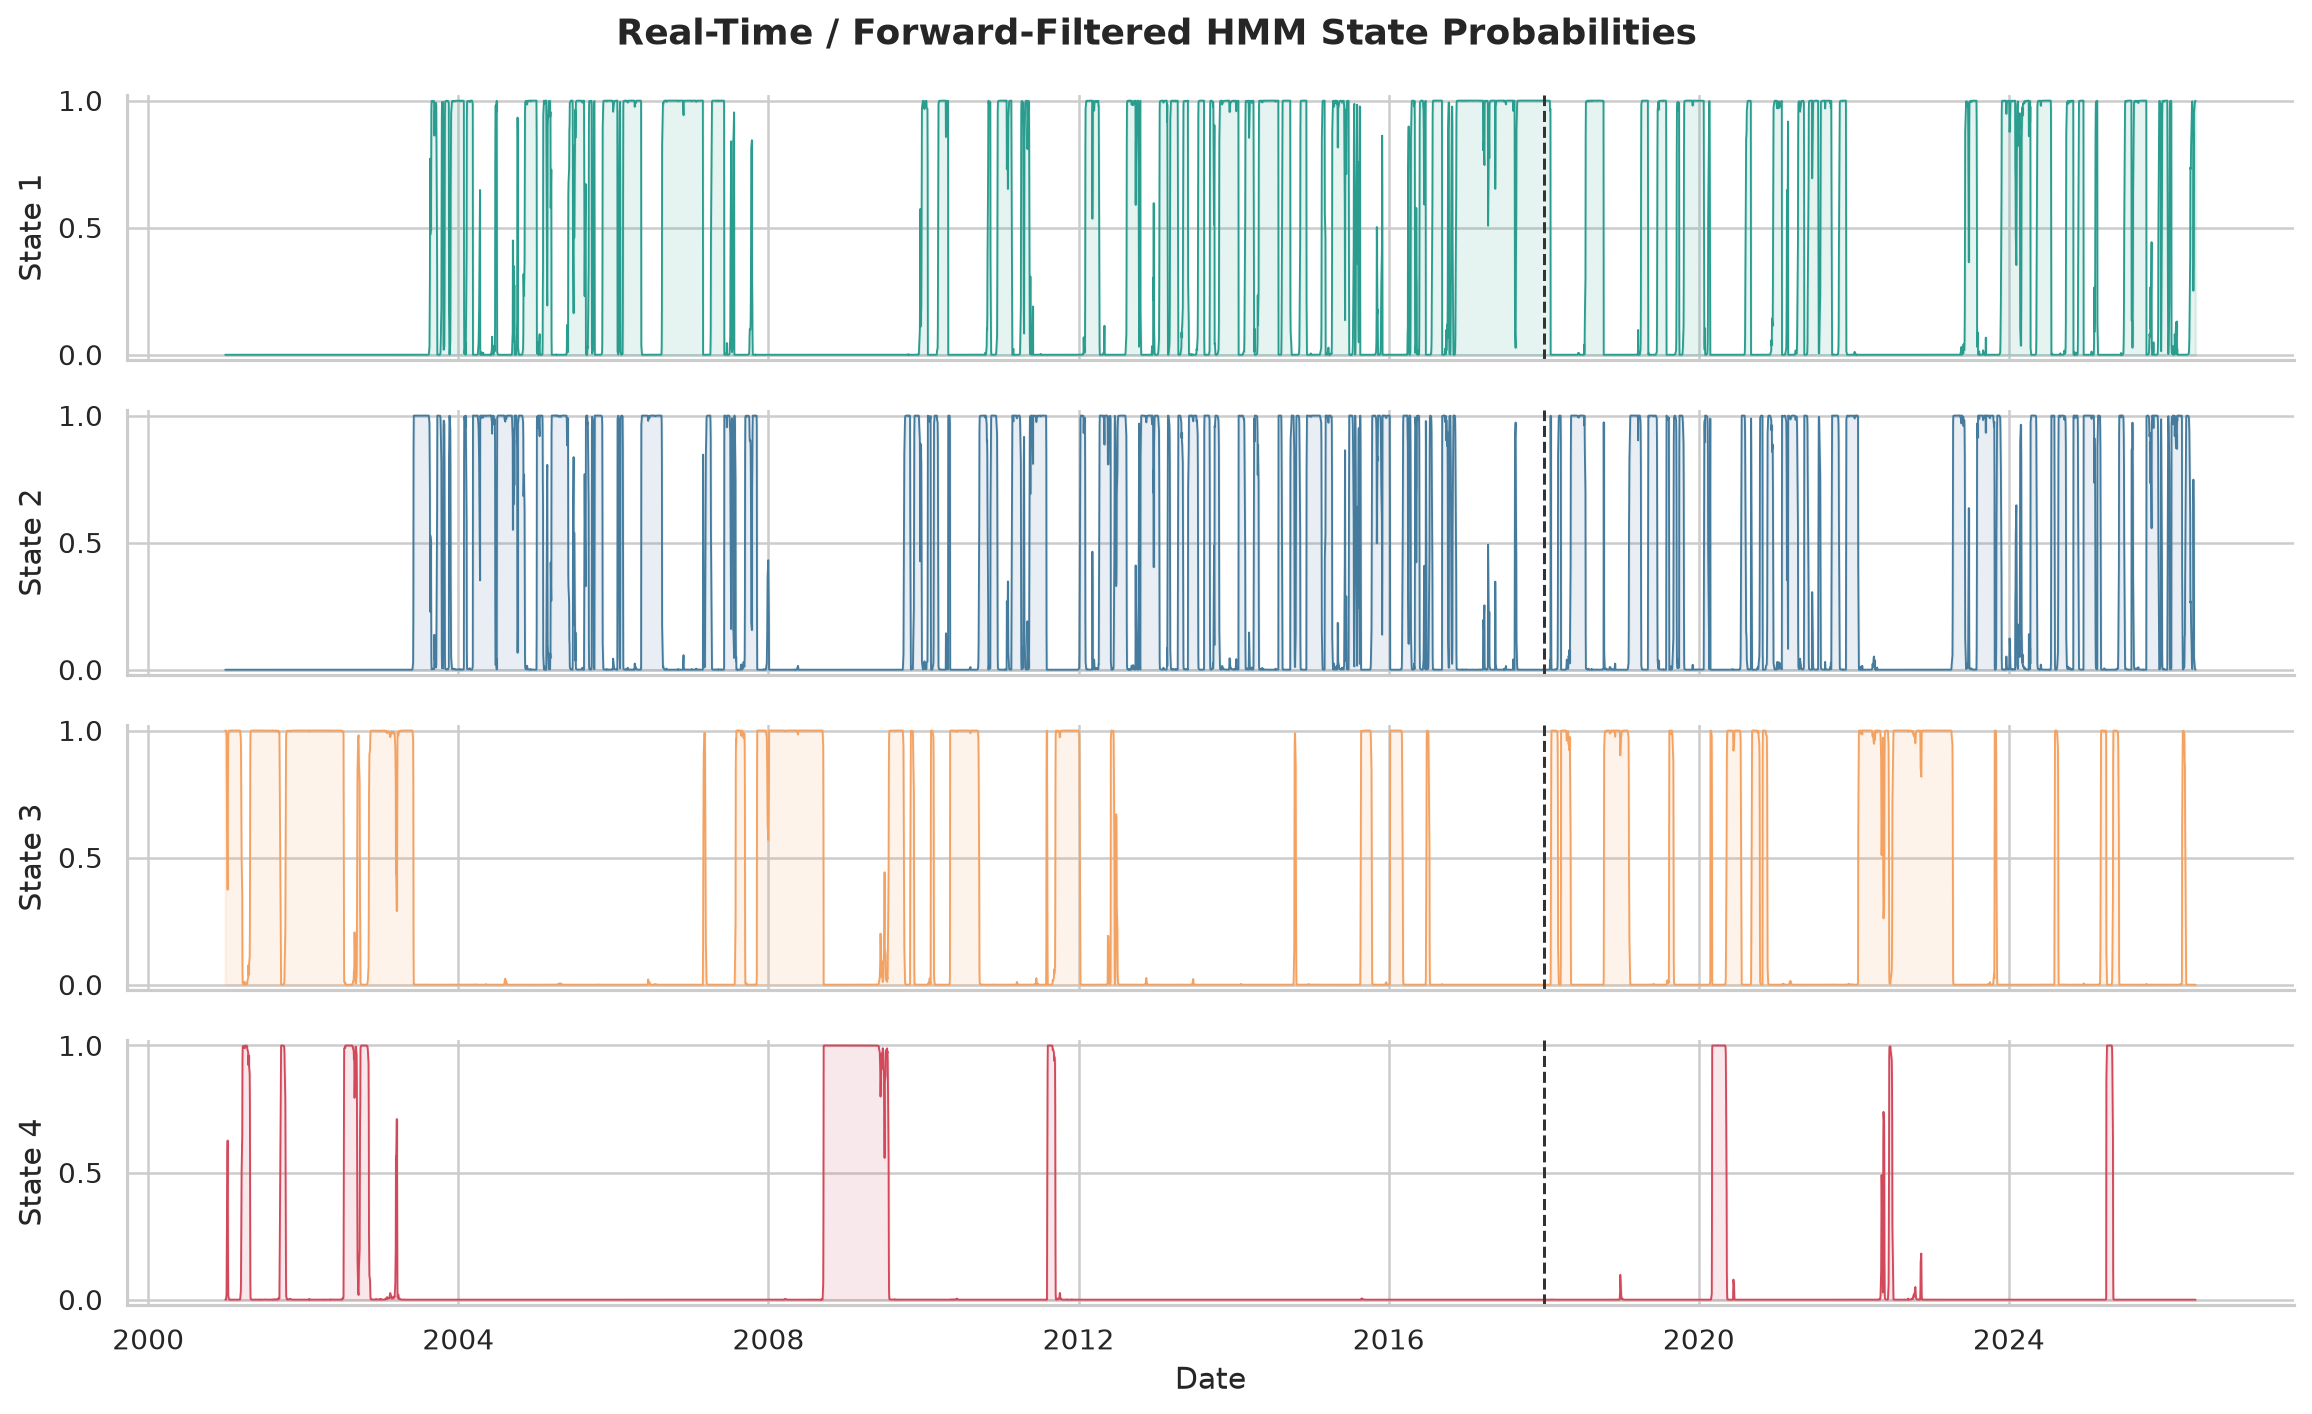

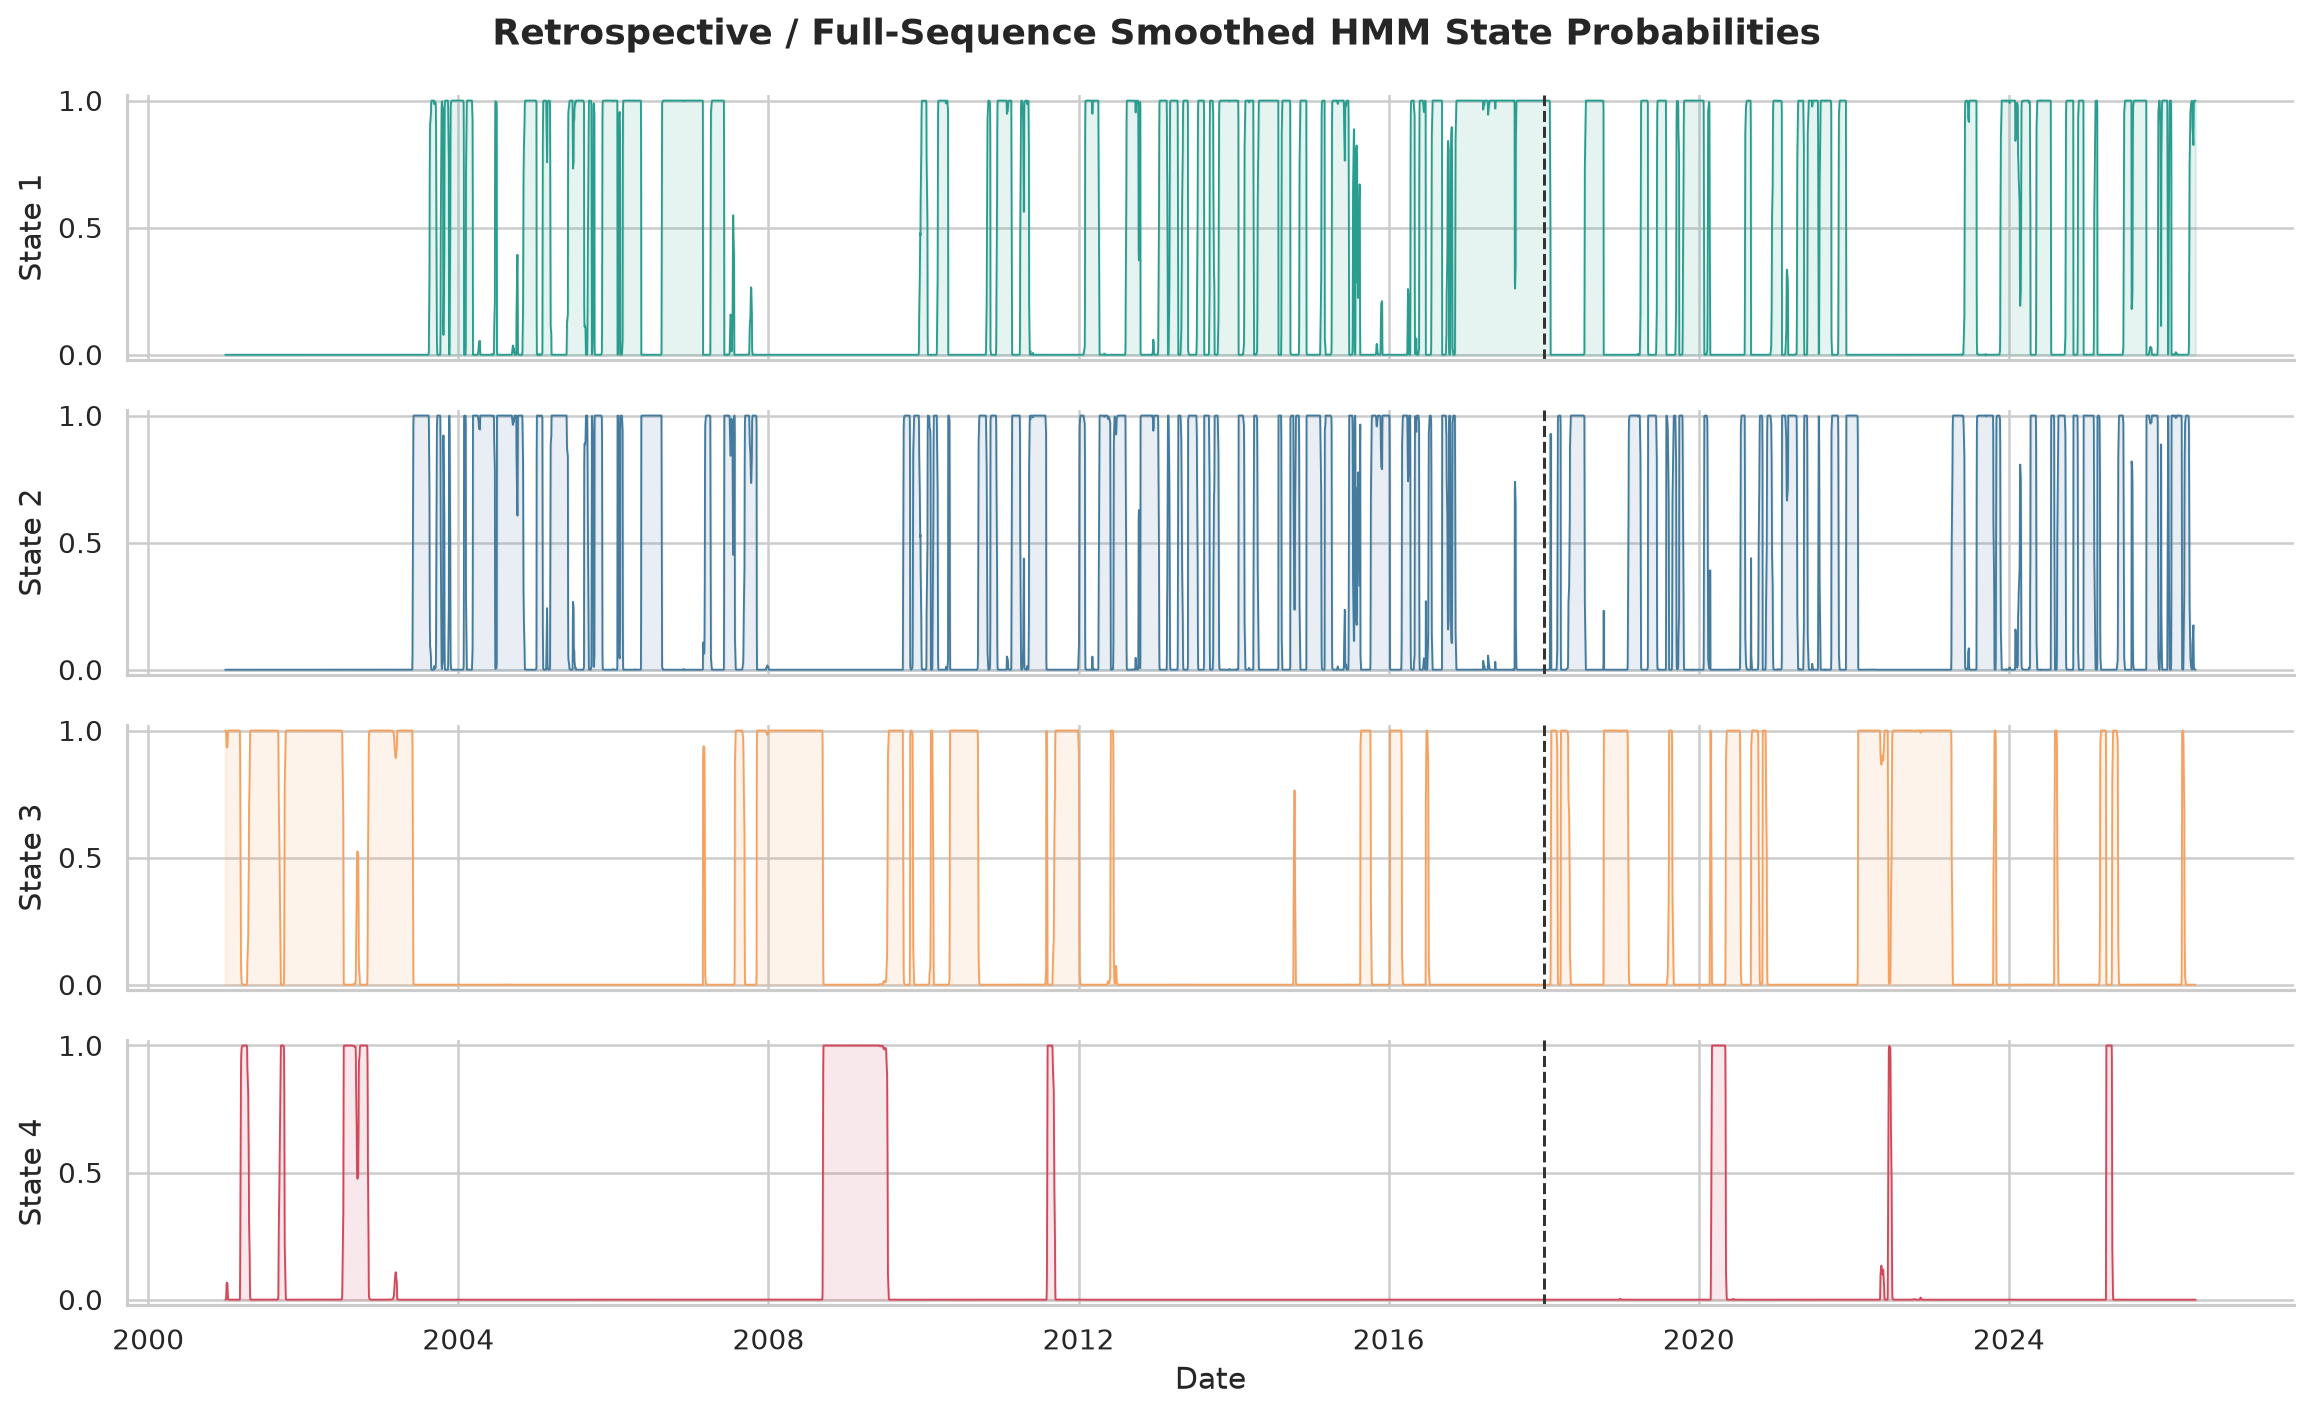

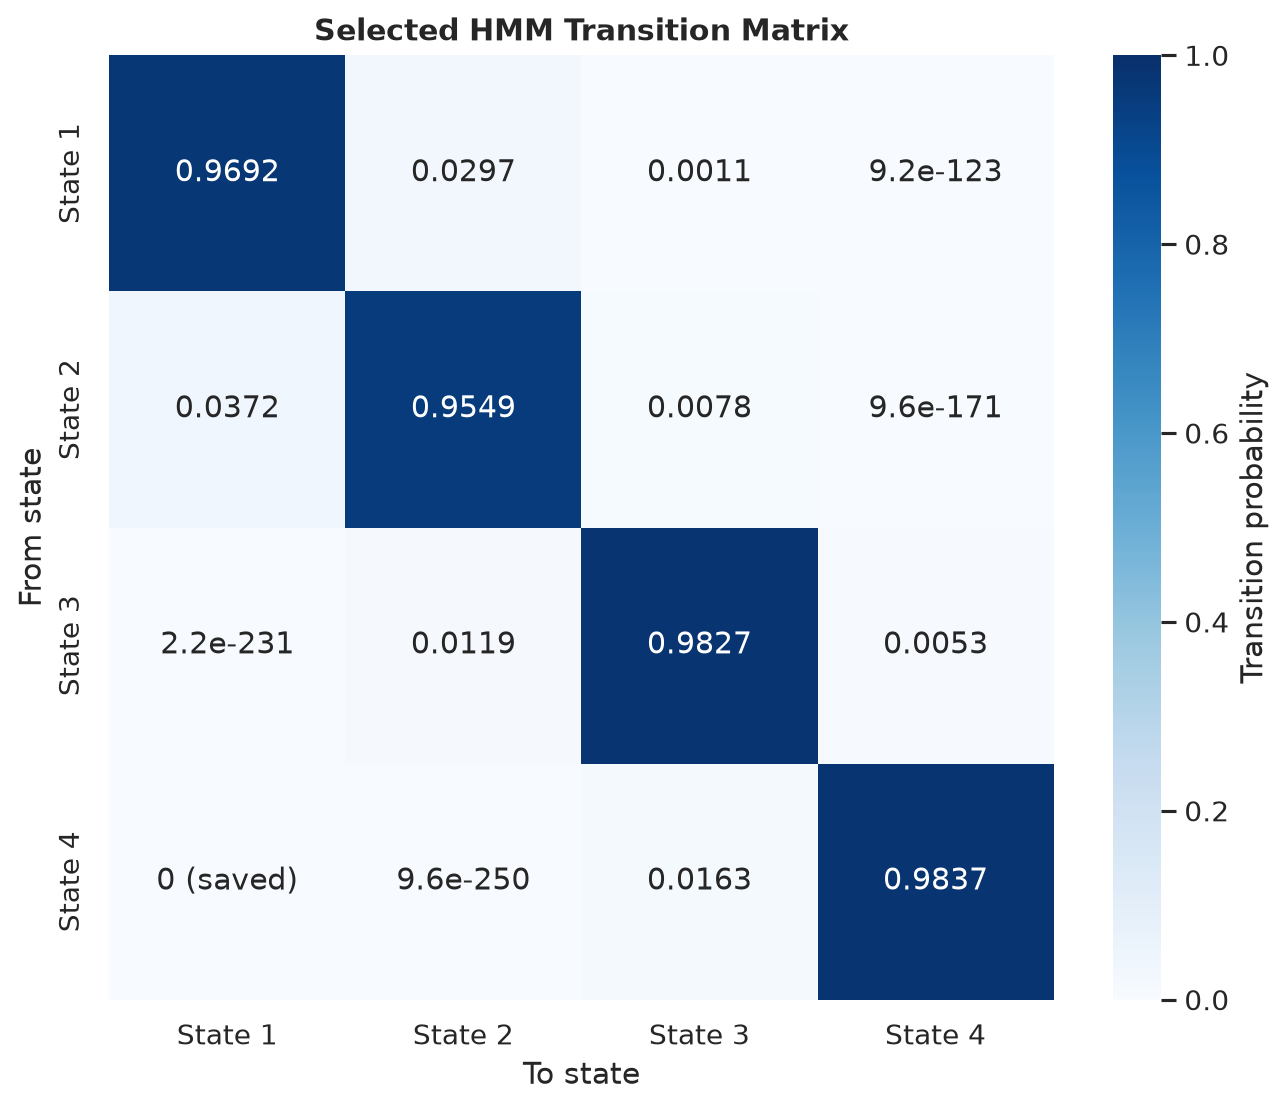

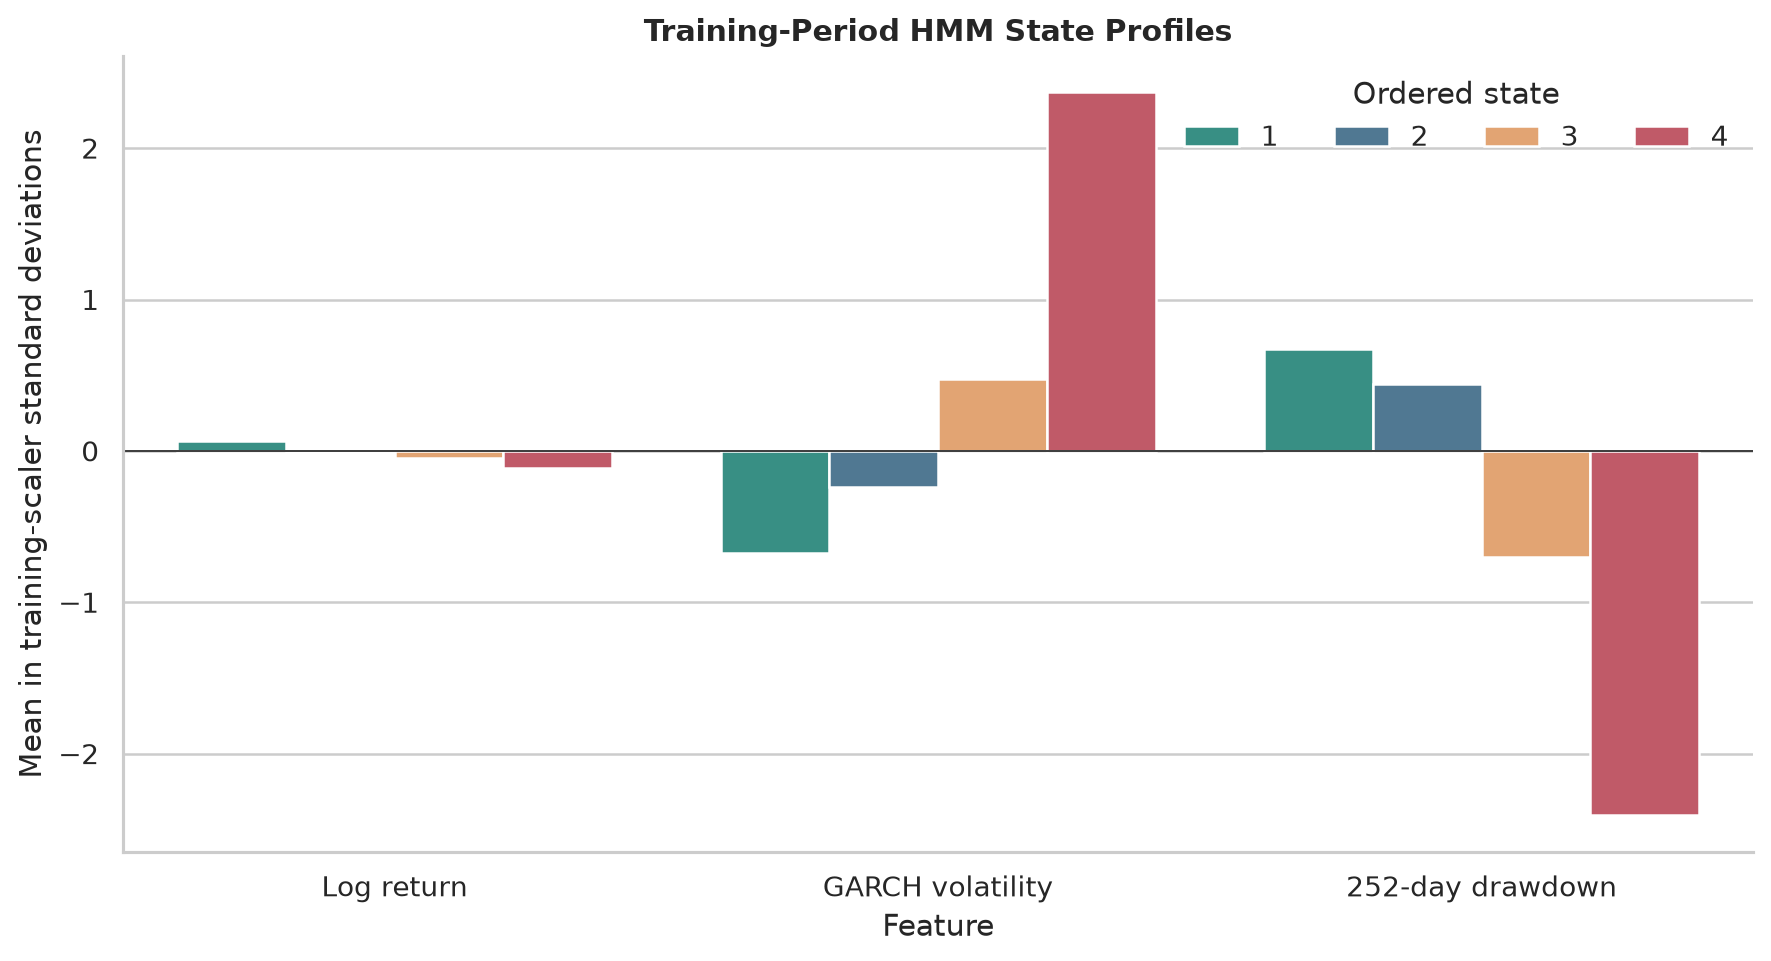

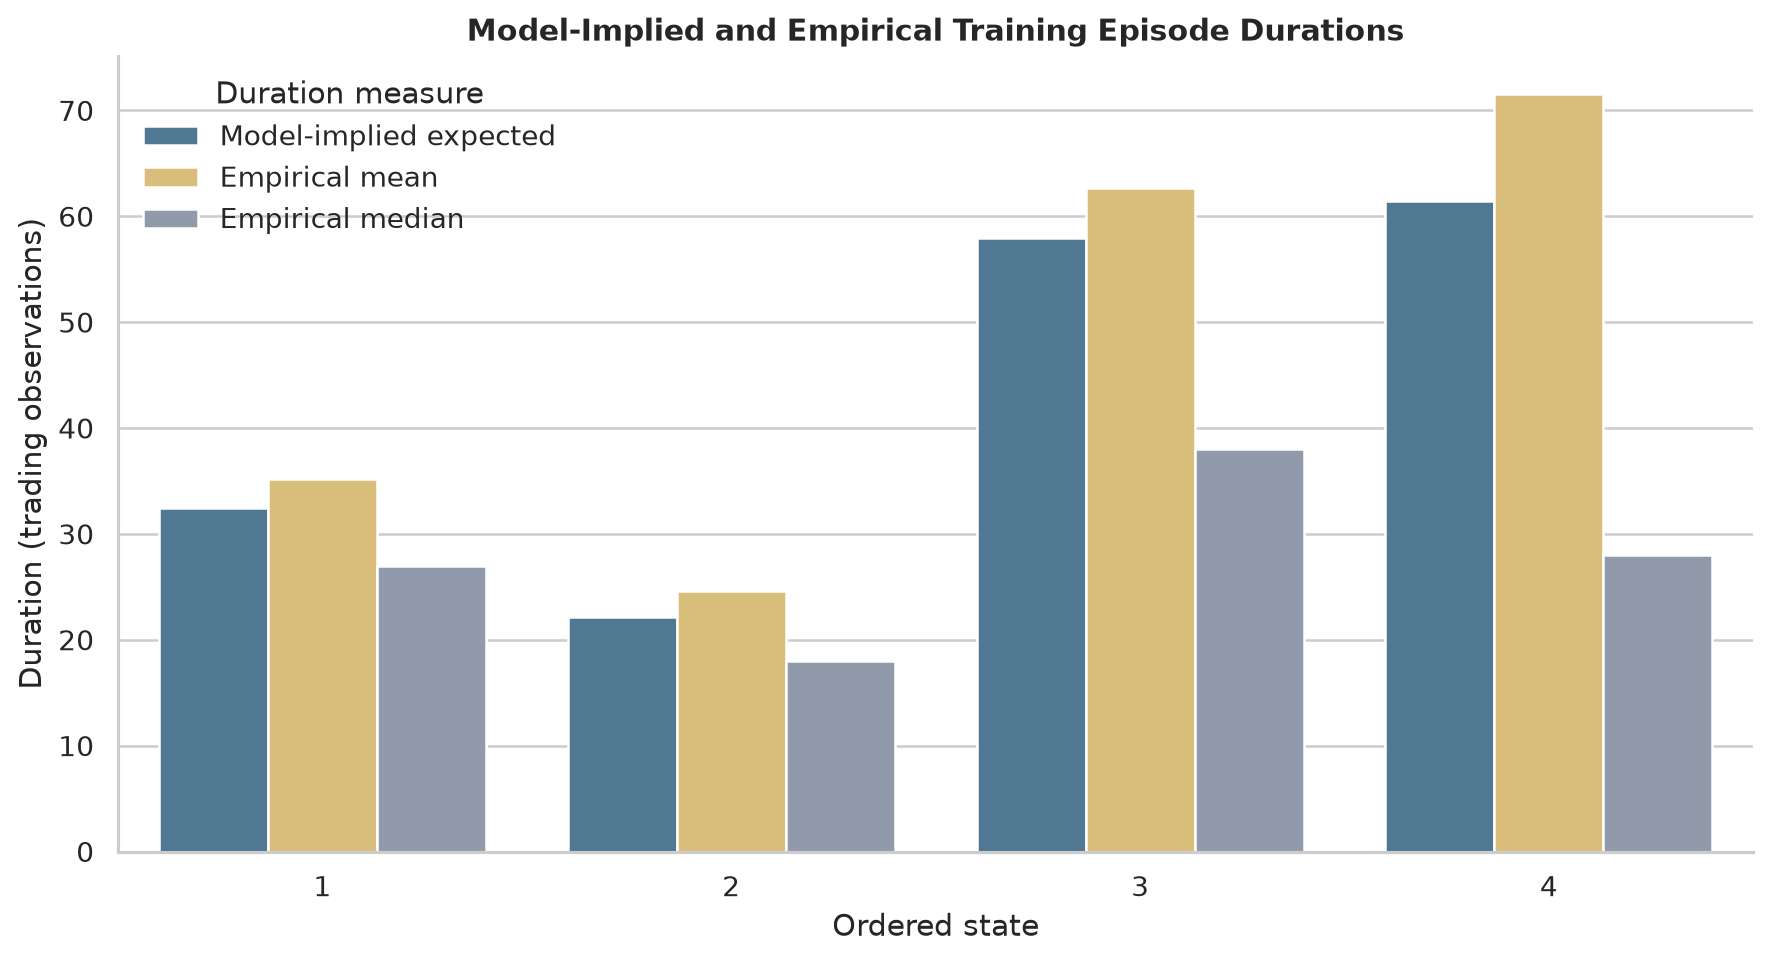

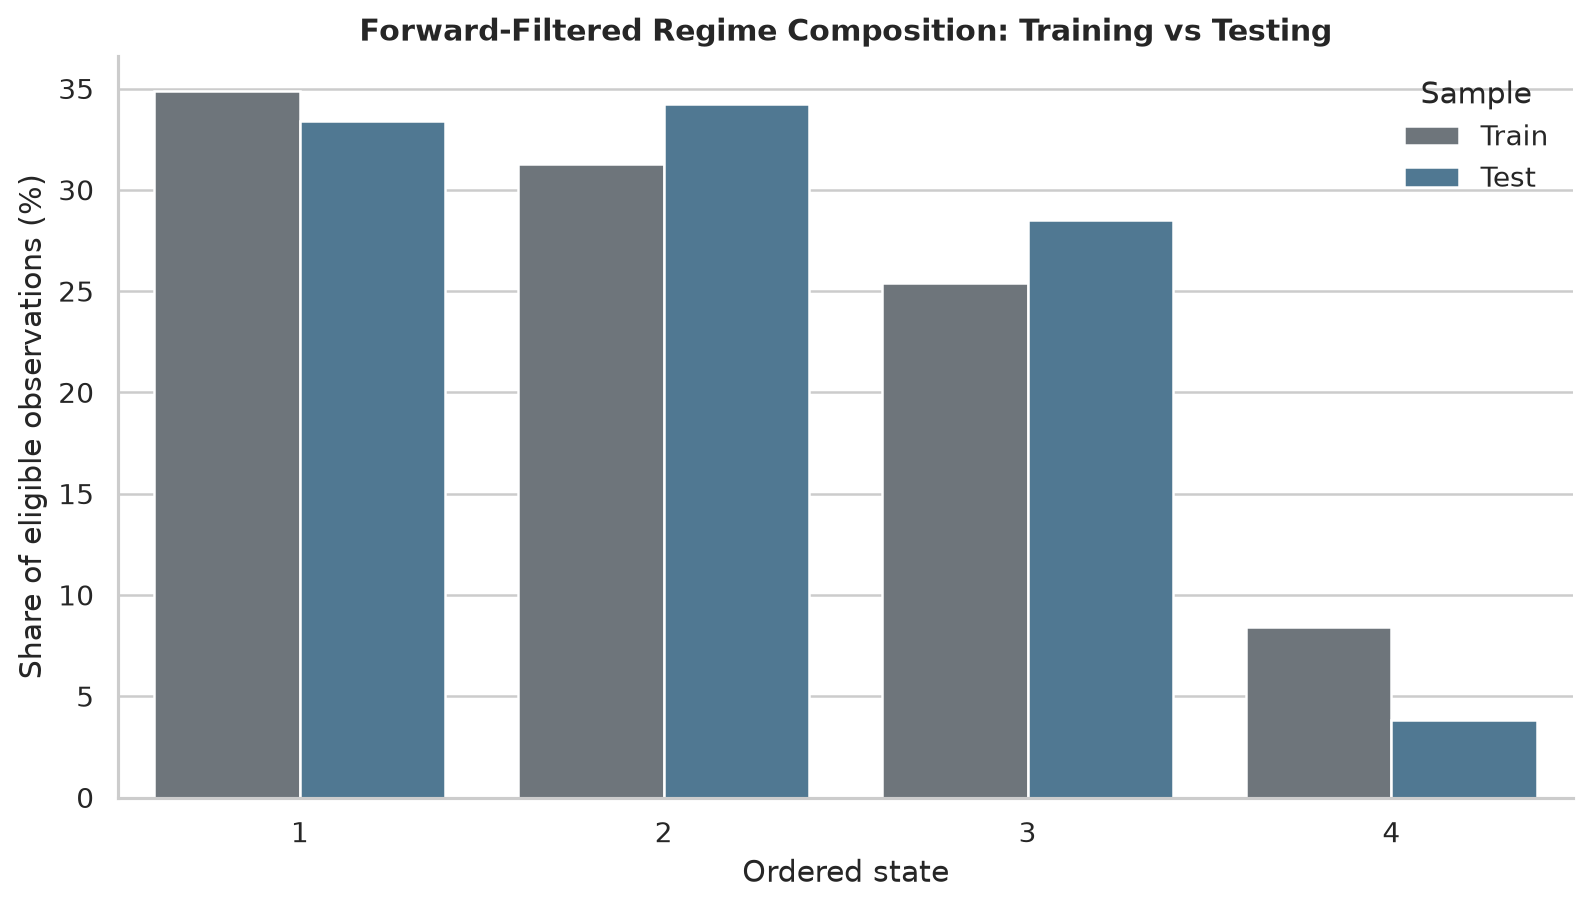

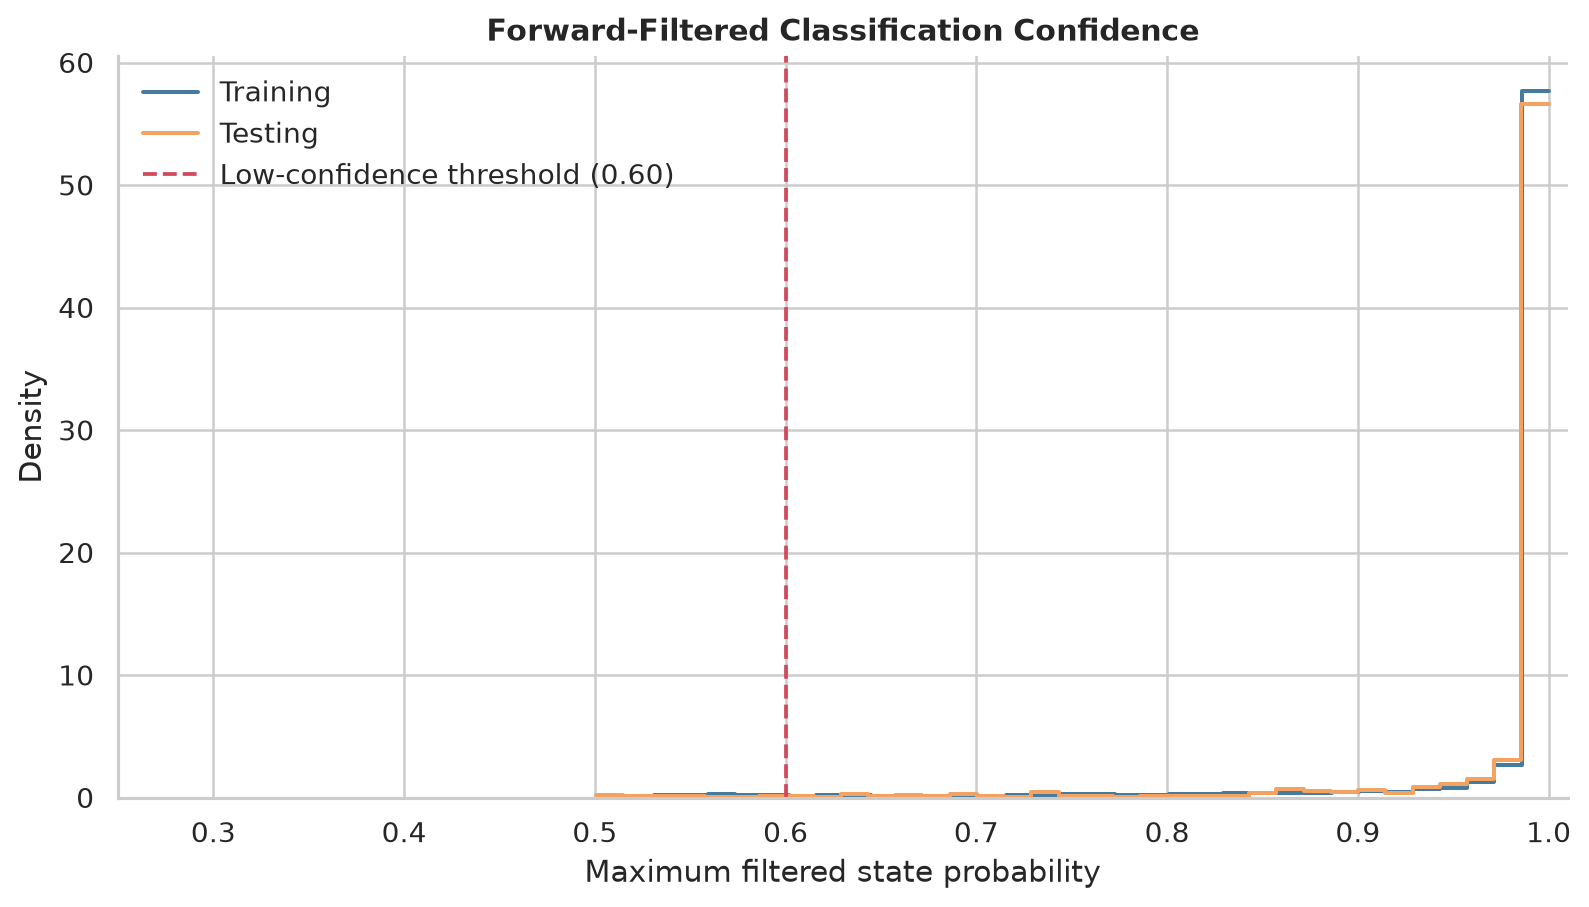

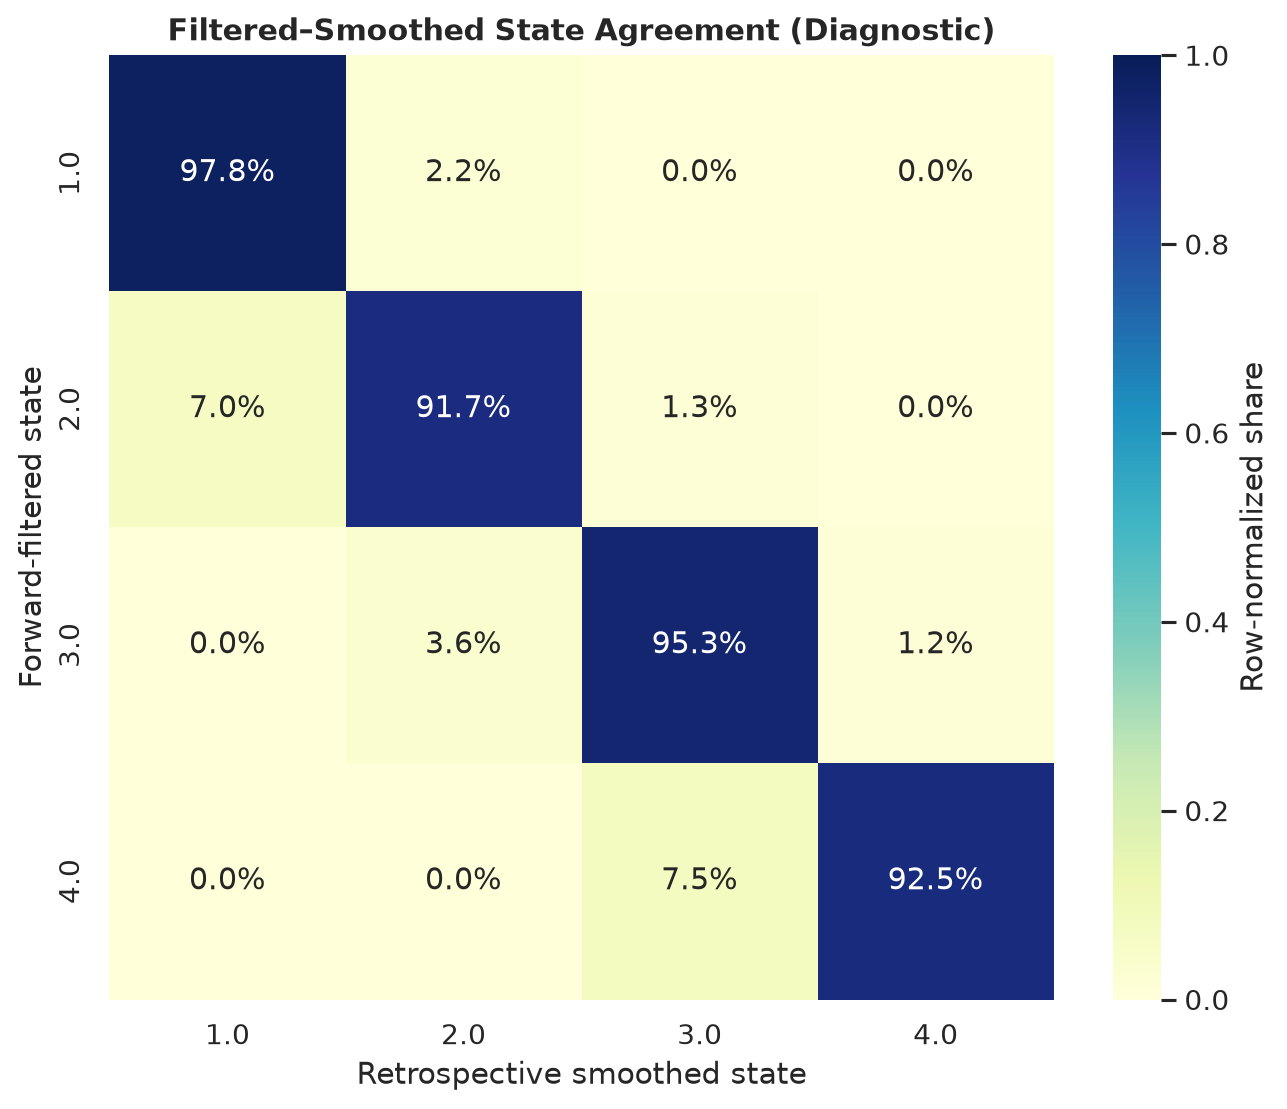

In [8]:
for path in figure_paths:
    display(Image(filename=str(path), width=950))

## 8. Limitations

- HMM states are estimated constructs, not directly observed economic truths.
- Gaussian emissions remain an approximation.
- Diagonal covariance restricts within-state contemporaneous covariance.
- State interpretations are post-estimation descriptions.
- GARCH volatility is highly persistent.
- Smoothed probabilities use future observations and must not become forecasting predictors.
- Regime identification alone does not establish volume predictability.
- Results may depend on feature definitions, the training cutoff, and the chosen number of states.

The figures and historical annotations are descriptive. They do not imply causation and were not used to fit, select, order, or name the model states.